<a href="https://colab.research.google.com/github/MiguelAtencio/deep-learning-copilot/blob/main/ML4BI_E1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Business Intelligence 2

# Exercise 1

In this exercise, the goal is to practice a couple of key steps from the the first lecture. Follow the instructions below.

### Step 1.

Import Necessary Libraries: First, import TensorFlow and other required libraries.

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

### Step 2.

Load the Fashion MNIST Dataset: Use Keras to load the dataset and split it into training and test sets.

In [36]:
# 1. Load the Fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

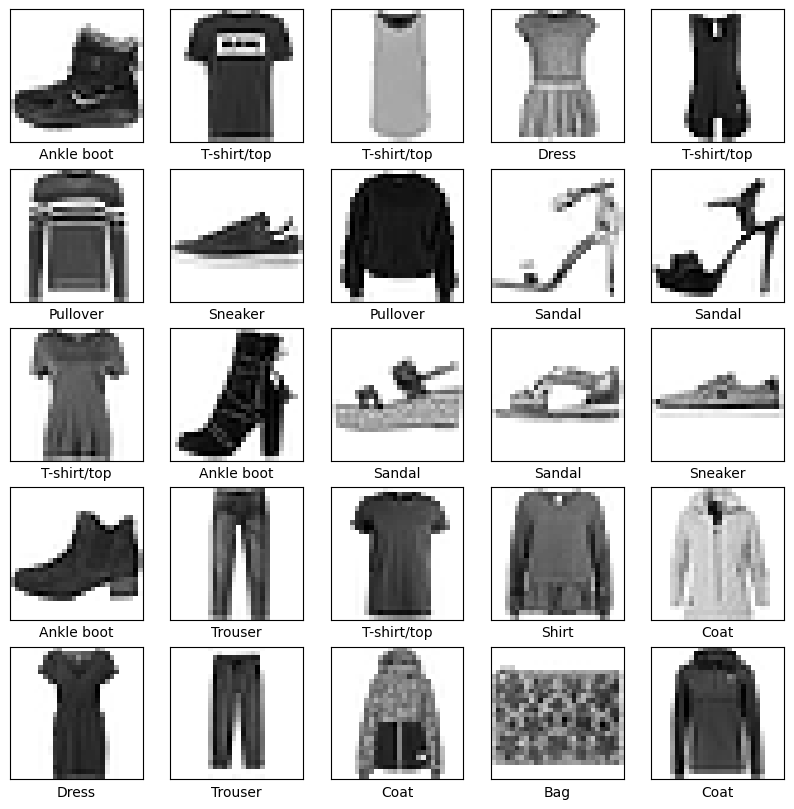

In [37]:
# Define class names to make the labels understandable
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Plot a few images from the training set
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    # The labels are integers, so you need the class_names array to get the corresponding label name
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [38]:
# 2. Preprocess the data:
# Transform images into a float32 array of shape (60000, 28, 28) with values in the 0-1 range
# Flattening the data
train_images = train_images.reshape(-1, 28 * 28).astype("float32") / 255.0
test_images = test_images.reshape(-1, 28 * 28).astype("float32") / 255.0

In [39]:
# 3. Build the model
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    # This will automatically take the input and feed it to the hidden layers
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [40]:
# 4. Compile the model
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [41]:
# 5. Train the model
model.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8016 - loss: 0.5628
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8599 - loss: 0.3840
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8739 - loss: 0.3406
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8834 - loss: 0.3149
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8912 - loss: 0.2958


In [42]:
# 6. Evaluate the model
test_loss, test_acc = model.evaluate(
    test_images,
    test_labels,
    verbose=2)

#PRINT TRAINING AND TEST ACCURACY
print(f"Training accuracy: {model.history.history['accuracy'][-1]:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 1s - 3ms/step - accuracy: 0.8796 - loss: 0.3332
Training accuracy: 0.8912
Test accuracy: 0.8796


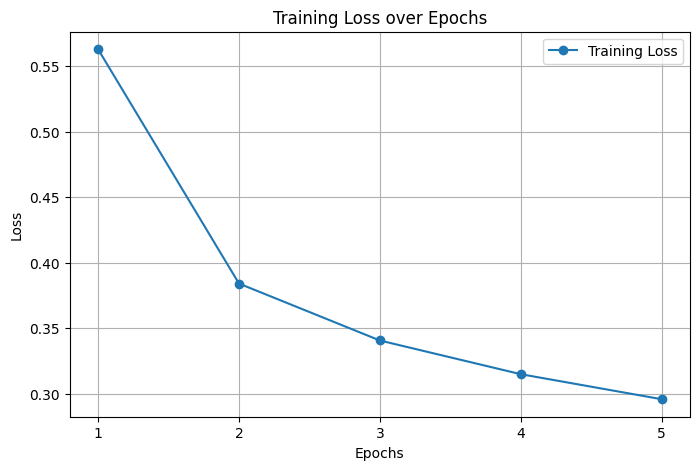

In [43]:
# 7. Plot training loss over epochs
history = model.history.history
epochs = range(1, len(history['loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['loss'], marker='o', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.show()